In [2]:
!pip install pandas numpy matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 4.7 MB/s  0:00:024.6 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 5.5 MB/s  0:00:005.5 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 5.2 MB/s  0:00:01m 5.2 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 5.3 MB/s  0:00:01m 5.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 4.5 MB/s  0:00:00m 4.5 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 4.5 MB/s  0:00:01m 4.5 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 4.5 MB/s  0:00:044.5 MB/s eta 0:00:01:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13 [matplotlib]7m━━━ 12/13 [matplotlib]n]


In [4]:
!pip install pandas numpy matplotlib scikit-learn jupyter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 5.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 4.4 MB/s  0:00:00m 4.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [jupyter]


Starting...
Libraries loaded
Loading dataset...
Dataset loaded: (500000, 16)
Encoding done
Splitting data
Scaling data
Training Logistic Regression...
Logistic Regression Results:
Accuracy: 0.5288
Precision: 0.013020277481323372
Recall: 0.40939597315436244
F1 Score: 0.025237898220935043
-------------------------
Training Random Forest...
Random Forest Results:
Accuracy: 0.9851
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
-------------------------

Final Comparison:
                  Model  Accuracy  Precision    Recall        F1
0  Logistic Regression    0.5288    0.01302  0.409396  0.025238
1        Random Forest    0.9851    0.00000  0.000000  0.000000


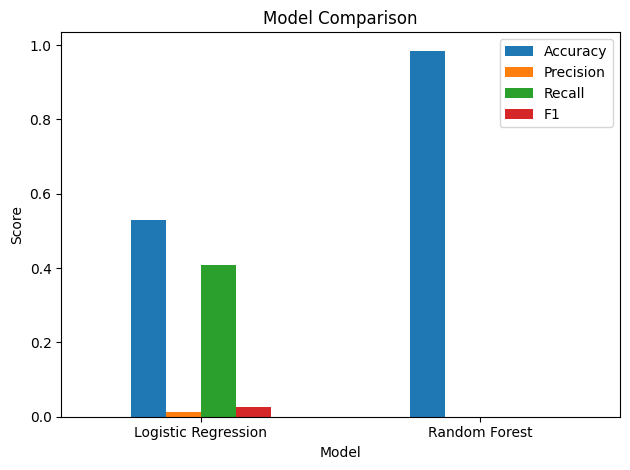

In [7]:
print("Starting...")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

print("Libraries loaded")

# LOAD DATA
print("Loading dataset...")

df = pd.read_csv("/Users/aakashreddy/Downloads/credit_card_fraud_2025.csv")

print("Dataset loaded:", df.shape)

# OPTIONAL: reduce size for speed (you can comment this later)
df = df.sample(50000, random_state=42)

# ENCODING
for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = LabelEncoder().fit_transform(df[col])

print("Encoding done")

# SPLIT
X = df.drop("Fraud_Flag", axis=1)
y = df["Fraud_Flag"]

print("Splitting data")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# SCALING
print("Scaling data")

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# MODELS 
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced')
}

results = []

# TRAINING
for name, model in models.items():
    print(f"Training {name}...")

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)

    print(f"{name} Results:")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("-------------------------")

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1
    })

# RESULTS TABLE
results_df = pd.DataFrame(results)
print("\nFinal Comparison:\n", results_df)

# Save table
results_df.to_csv("model_results.csv", index=False)

# PLOT
results_df.set_index("Model").plot(kind="bar")
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("model_comparison.pdf")
plt.show()